# Performance analysis of the different bots

## Performance analysis - LinearSearchBot

LinearSearchbot simply starts by guessing 1, then 2, then 3, and so on. It is probably the simplest way to guarantee that you eventually guess the correct number, but it is very slow.

Given a maximum guess value $N_\text{max}$, if the target value is $n < N_\text{max}$, it requires exactly $n$ guesses to win. Since the target number is chosen from a uniform random distribution $P(i = n) = 1 / N_\text{max}$, the number of guesses should also follow the same uniform distribution.

This can be demonstrated by running 50,000 games with a maximum target value of 1,000.

In [2]:
"""Running experiment with linear search bot"""
import matplotlib.pyplot as plt

from numbergame.game import Game
from numbergame.bots import LinearSearchBot
from numbergame.statistics import RunStatistics


N_MAX = 1_000
N_RUNS = 50_000

bot = LinearSearchBot()
game = Game(bot, max_target=N_MAX)

statistics_single_run = RunStatistics(LinearSearchBot, [game.run() for _ in range(N_RUNS)])
statistics_single_run

RunStatistics(bottype='LinearSearchBot', n_total=50000, n_sucess=50000, mean=501.44176, std=289.52886430780563, quarentiles=QuartilesInfo(minimum=1, quarentile_25=247, median=505, quarentile_75=752, maximum=1000), completion_percentage=100.0)

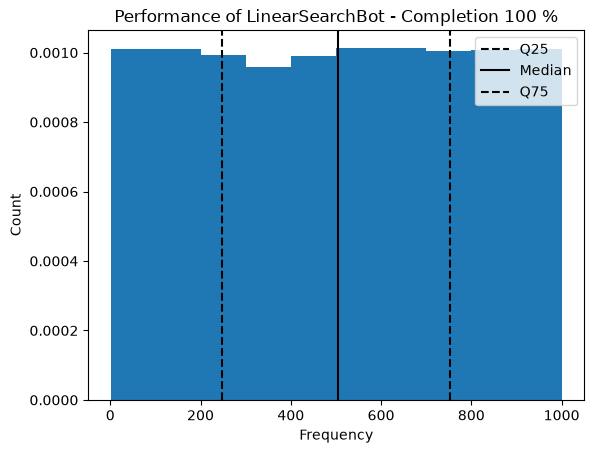

In [3]:
fig, ax = statistics_single_run.plot(density=True)
ax.set_xlabel('Frequency')
ax.legend()

As you can see, the number of guesses is uniformly distributes.

### Expected performance of LinearSearchBot

The expected performance of the linear bot if easy to calculate since the relationship between the number of guesses $i$ and target score $n$ is as simple as it is: $i = n$.

$$
    \left\langle n \right\rangle 
        = \sum_{i = 1}^{N_\text{max}} i\ P(n = i) 
        = \frac{1}{N_\text{max}} \sum_{i = 1}^{N_\text{max}} i
        = \frac{1}{N_\text{max}} \frac{N_\text{max}(N_\text{max} + 1)}{2} 
        = \frac{N_\text{max} + 1}{2} 
$$

The expected performance is linear with $N_\text{max}$ also written as $\mathcal{O}(N_\text{max})$. This can be demonstrated by running a large amount of simulations for different values of $N_\text{max}$, the results of which are treated using the same method as before.


In [4]:
"""
Running 10_000 simulations for each size in [100, 200, 300, ..., 1_000]
"""
import time
import numpy as np

N_RUNS = 10_000
bot = LinearSearchBot()

sizes = [int(x) for x in np.arange(100, 1_000, step=100, dtype=int)]

dataset_linear_search_bot = {}
for n_max in sizes:
    print(f"Measure data for {n_max=} in: ", end="")
    game = Game(bot, max_target=n_max, max_questions=50_000)
    t_start = time.perf_counter()
    dataset_linear_search_bot[n_max] = RunStatistics(LinearSearchBot, [game.run() for _ in range(N_RUNS)])
    t_end = time.perf_counter()
    print(f"{t_end - t_start:0.1f} seconds")
dataset_linear_search_bot

Measure data for n_max=100 in: 0.2 seconds
Measure data for n_max=200 in: 0.4 seconds
Measure data for n_max=300 in: 0.6 seconds
Measure data for n_max=400 in: 0.7 seconds
Measure data for n_max=500 in: 1.0 seconds
Measure data for n_max=600 in: 1.1 seconds
Measure data for n_max=700 in: 1.3 seconds
Measure data for n_max=800 in: 1.5 seconds
Measure data for n_max=900 in: 1.9 seconds


{100: RunStatistics(bottype='LinearSearchBot', n_total=10000, n_sucess=10000, mean=51.1696, std=28.911209273258777, quarentiles=QuartilesInfo(minimum=1, quarentile_25=26, median=52, quarentile_75=76, maximum=100), completion_percentage=100.0),
 200: RunStatistics(bottype='LinearSearchBot', n_total=10000, n_sucess=10000, mean=101.1514, std=57.85515361590523, quarentiles=QuartilesInfo(minimum=1, quarentile_25=51, median=101, quarentile_75=151, maximum=200), completion_percentage=100.0),
 300: RunStatistics(bottype='LinearSearchBot', n_total=10000, n_sucess=10000, mean=150.6095, std=86.76738712037357, quarentiles=QuartilesInfo(minimum=1, quarentile_25=75, median=152, quarentile_75=226, maximum=300), completion_percentage=100.0),
 400: RunStatistics(bottype='LinearSearchBot', n_total=10000, n_sucess=10000, mean=200.141, std=116.52125574033232, quarentiles=QuartilesInfo(minimum=1, quarentile_25=99, median=199, quarentile_75=302, maximum=400), completion_percentage=100.0),
 500: RunStatistic

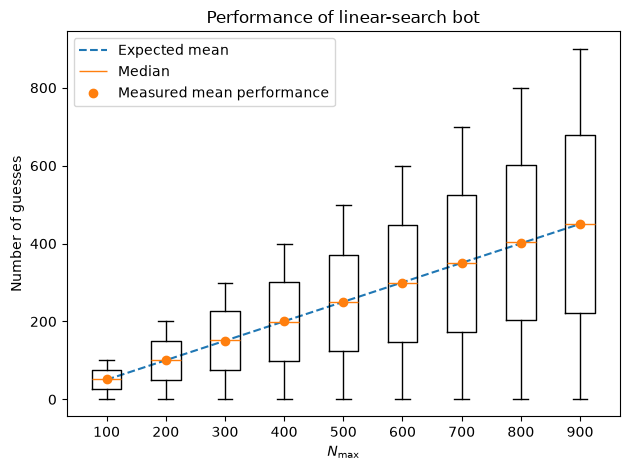

In [5]:
import numpy as np

size_array = np.array(list(dataset_linear_search_bot), dtype=int)
data_array = np.array([data.quarentiles for data in dataset_linear_search_bot.values()]).T


fig, ax = plt.subplots()
ax.plot(size_array, 0.5 * (size_array + 1), '--', label='Expected mean')
ax.boxplot(data_array,
           positions=list(dataset_linear_search_bot), 
           widths=(sizes[1] - sizes[0]) // 2,
           label='Median')
ax.plot(size_array, [data.mean for data in dataset_linear_search_bot.values()], 'o', label='Measured mean performance')

ax.set_xlabel('$N_\\text{max}$')
ax.set_ylabel('Number of guesses')
ax.set_title('Performance of linear-search bot')
ax.legend()
fig.tight_layout()

Box plot of the performance of LinearBot. The boxes shows the mediant performance, indicated by the <span style="color:orange;">orange</span> line. The borders of the box denotes the 25- and 75-quartiles and the ends of the lines denotes the minimum and maximum score.

### Average spread

As you can see in the above the average performance is linear with the maximum guess value. But the results are also more spread. One way is quantizing this spread is by using box plots as above. Another way is to use the standard deviation $\sigma = \sqrt{\left\langle n^2\right\rangle - \left\langle n\right\rangle^2}$.  


The average score 


$$
    \left\langle n^2 \right\rangle 
        = \sum_{i = 1}^{N_\text{max}} i^2 P(n = i) 
        = \frac{1}{N_\text{max}} \sum_{i = 1}^{N_\text{max}} i^2
        = \frac{1}{N_\text{max}} \frac{N_\text{max}(N_\text{max} + 1)(2N_\text{max} + 1)}{6} 
        = \frac{(N_\text{max} + 1)(2N_\text{max} + 1)}{6}
$$

$$
    \sigma = \sqrt{\left\langle n^2 \right\rangle - \left\langle n \right\rangle^2} = \frac{1}{2\sqrt{3}}\sqrt{N^2 - 1} \sim N
$$


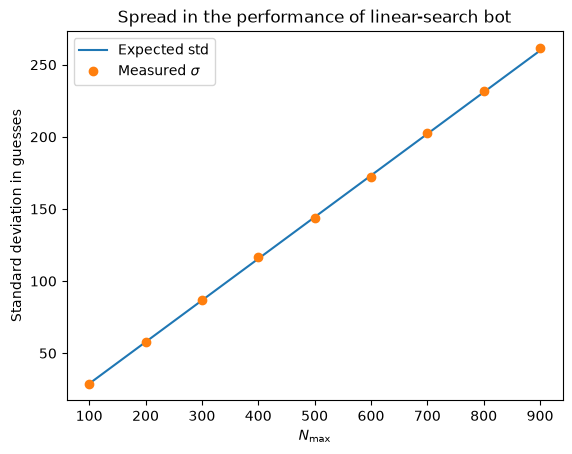

In [6]:
def expected_std(size):
    return np.sqrt((size*size - 1) / 12)


fig, ax = plt.subplots()
ax.plot(size_array, expected_std(size_array), '-', label='Expected std')
ax.plot(size_array, [data.std for data in dataset_linear_search_bot.values()], 'o', label=r'Measured $\sigma$')

ax.set_xlabel('$N_\\text{max}$')
ax.set_ylabel('Standard deviation in guesses')
ax.set_title('Spread in the performance of linear-search bot')
ax.legend()

As you can see, the spread in performance also growns linear with the maximum-guess value $\sigma = \mathcal{O}(N_\text{max})$.

### Conclusion

Althou the LinearSearchBot in guarenteed to guess the target value, its performance is not particularly impressive. Its results spans uniformly from guessing the target on the first guess to guessing all numbers.

## Performance of RandoBot

RandoBot is not the brightest kid in class. Its guesses are completly random within the bounds of the question: $[1, N_\text{max}]$. 

In [7]:
"""Running experiment with RandoBot"""
import matplotlib.pyplot as plt

from numbergame.game import Game
from numbergame.bots import RandoBot
from numbergame.statistics import RunStatistics


N_MAX = 1_000
N_RUNS = 50_000

bot = RandoBot()
game = Game(bot, max_target=N_MAX, max_questions=10_000)

statistics_single_run = RunStatistics(RandoBot, [game.run() for _ in range(N_RUNS)])
statistics_single_run

RunStatistics(bottype='RandoBot', n_total=50000, n_sucess=50000, mean=1001.77652, std=1012.7524693665149, quarentiles=QuartilesInfo(minimum=1, quarentile_25=282, median=686, quarentile_75=1389, maximum=9653), completion_percentage=100.0)

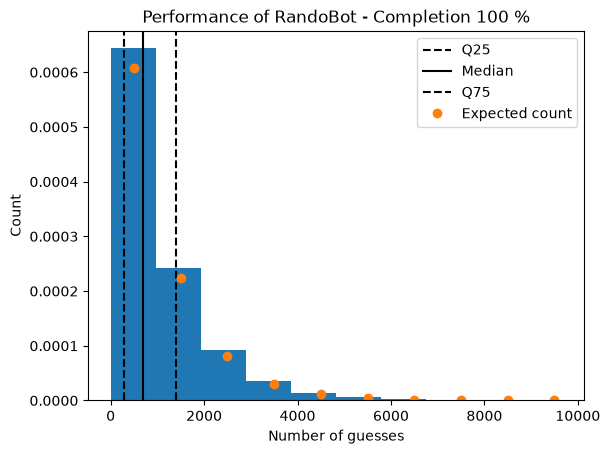

In [8]:
import numpy as np

f = 1 / N_MAX
fig, ax = statistics_single_run.plot(density=True)
x = np.arange(500, 10_000, step=1_000)
ax.plot(x, (1 - f)**(x - 1)*f, 'o', label='Expected count')
ax.legend()

### Average performance of RandoBot

$$
    \left\langle n \right\rangle 
        = \sum_{i = 1}^\infty i\ P(\text{score} = i)
        = \sum_{i = 1}^\infty i (1 - f)^{i - 1} f
        % = f \frac{d}{dx} \sum_{i=0}^\infty x^i \Big|_{x = 1 - f}
        % = f \frac{d}{dx} \frac{1}{1 - x} \Big|_{x = 1 - f}
        % = \frac{f}{(1 - x)^2}\Big|_{x = 1 - f}
        = f^{-1} 
        = N_\text{max}
$$

In [9]:
"""
Running 10_000 simulations for each size in [100, 200, 300, ..., 1_000]
"""
import time
import numpy as np

N_RUNS = 10_000
bot = RandoBot()

sizes = [int(x) for x in np.arange(100, 1_000, step=100, dtype=int)]

dataset_randobot = {}
for n_max in sizes:
    print(f"Measure data for {n_max=} in: ", end="")
    game = Game(bot, max_target=n_max, max_questions=50_000)
    t_start = time.perf_counter()
    dataset_randobot[n_max] = RunStatistics(RandoBot, [game.run() for _ in range(N_RUNS)])
    t_end = time.perf_counter()
    print(f"{t_end - t_start:0.1f} seconds")
dataset_randobot

Measure data for n_max=100 in: 0.6 seconds
Measure data for n_max=200 in: 1.0 seconds
Measure data for n_max=300 in: 1.7 seconds
Measure data for n_max=400 in: 2.3 seconds
Measure data for n_max=500 in: 2.6 seconds
Measure data for n_max=600 in: 3.5 seconds
Measure data for n_max=700 in: 3.9 seconds
Measure data for n_max=800 in: 4.6 seconds
Measure data for n_max=900 in: 4.7 seconds


{100: RunStatistics(bottype='RandoBot', n_total=10000, n_sucess=10000, mean=99.711, std=98.64230689451126, quarentiles=QuartilesInfo(minimum=1, quarentile_25=30, median=68, quarentile_75=136, maximum=718), completion_percentage=100.0),
 200: RunStatistics(bottype='RandoBot', n_total=10000, n_sucess=10000, mean=197.5535, std=199.3147946753769, quarentiles=QuartilesInfo(minimum=1, quarentile_25=56, median=138, quarentile_75=271, maximum=1869), completion_percentage=100.0),
 300: RunStatistics(bottype='RandoBot', n_total=10000, n_sucess=10000, mean=297.3037, std=295.24492717574725, quarentiles=QuartilesInfo(minimum=1, quarentile_25=87, median=205, quarentile_75=410, maximum=2480), completion_percentage=100.0),
 400: RunStatistics(bottype='RandoBot', n_total=10000, n_sucess=10000, mean=404.6304, std=403.8796871297288, quarentiles=QuartilesInfo(minimum=1, quarentile_25=116, median=281, quarentile_75=563, maximum=4105), completion_percentage=100.0),
 500: RunStatistics(bottype='RandoBot', n_

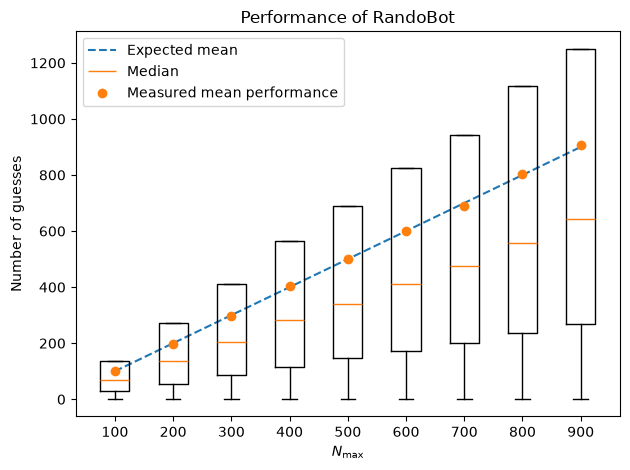

In [10]:
import numpy as np

size_array = np.array(list(dataset_randobot), dtype=int)
data_array = np.array([data.quarentiles for data in dataset_randobot.values()]).T

fig, ax = plt.subplots()
ax.plot(size_array, size_array, '--', label='Expected mean')
ax.boxplot(data_array,
           positions=list(dataset_randobot),
           widths=(sizes[1] - sizes[0]) // 2,
           showfliers=False,
           label='Median')
ax.plot(size_array, [data.mean for data in dataset_randobot.values()], 'o', label='Measured mean performance')

ax.set_xlabel('$N_\\text{max}$')
ax.set_ylabel('Number of guesses')
ax.set_title('Performance of RandoBot')
ax.legend()
fig.tight_layout()

### Average spread of RandoBot
 

$$
    \left\langle n^2 \right\rangle 
        = \sum_{i = 1}^\infty i^2\ P(\text{score} = i)
        = \sum_{i = 1}^\infty i^2 (1 - f)^{i - 1} f
        = f \sum_{i = 1}^\infty [(i+1)\ i\ x^{i - 1} f - i\ x^{i - 1}] \Big|_{x = 1 - f}
        = 2N_\text{max}^2 - N_\text{max}
$$

$$
    \sigma^2 =  N_\text{max}\left(N_\text{max} - 1\right)
$$

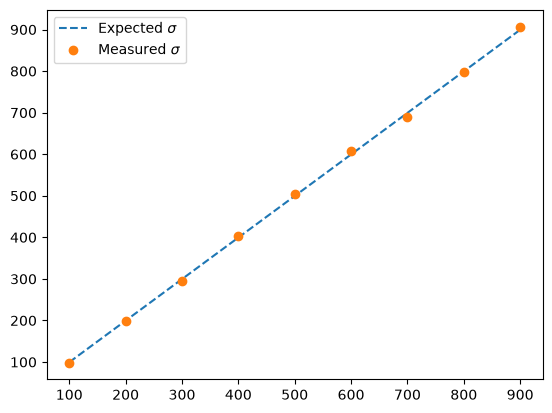

In [11]:
fig, ax = plt.subplots()
ax.plot(size_array, np.sqrt(size_array*(size_array - 1)), '--', label=r'Expected $\sigma$')
ax.plot(size_array, [data.std for data in dataset_randobot.values()], 'o', label=r'Measured $\sigma$')
ax.legend()

## Performance analysis - BinarySearchBot


![Binary search tree](./binarySearchTree.png)

In [12]:
"""Running experiment with linear search bot"""
import matplotlib.pyplot as plt

from numbergame.game import Game
from numbergame.bots import BinarySearchBot
from numbergame.statistics import RunStatistics


N_MAX = 50_000
N_RUNS = 50_000

bot = BinarySearchBot()
game = Game(bot, max_target=N_MAX)

statistics_single_run = RunStatistics(LinearSearchBot, [game.run() for _ in range(N_RUNS)])
statistics_single_run

RunStatistics(bottype='LinearSearchBot', n_total=50000, n_sucess=50000, mean=14.6808, std=1.4987315583271337, quarentiles=QuartilesInfo(minimum=2, quarentile_25=14, median=15, quarentile_75=16, maximum=16), completion_percentage=100.0)

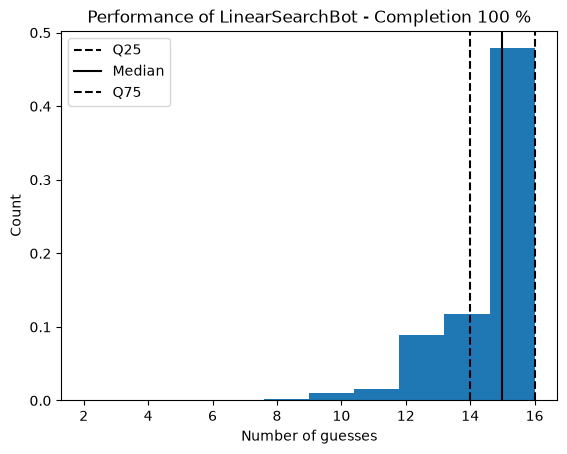

In [13]:
fig, ax = statistics_single_run.plot(density=True)
# ax.plot(x, (1 - f)**(x - 1)*f, 'o', label='Expected count')
ax.legend()

## Average performance of binary search bot

In [14]:
"""
Running 10_000 simulations for each size in [100, 500, 1_000, 5_000, 10_000, 50_000, 100_000]
"""
import time
import numpy as np

N_RUNS = 10_000
bot = BinarySearchBot()

sizes = [100, 500, 1_000, 5_000, 10_000, 50_000, 100_000, 500_000, 1_000_000]

dataset_binary_search_bot = {}
for n_max in sizes:
    print(f"Measure data for {n_max=} in: ", end="")
    game = Game(bot, max_target=n_max, max_questions=50_000)
    t_start = time.perf_counter()
    dataset_binary_search_bot[n_max] = RunStatistics(BinarySearchBot, [game.run() for _ in range(N_RUNS)])
    t_end = time.perf_counter()
    print(f"{t_end - t_start:0.1f} seconds")
dataset_binary_search_bot

Measure data for n_max=100 in: 2.5 seconds
Measure data for n_max=500 in: 0.6 seconds
Measure data for n_max=1000 in: 0.6 seconds
Measure data for n_max=5000 in: 0.1 seconds
Measure data for n_max=10000 in: 0.1 seconds
Measure data for n_max=50000 in: 0.1 seconds
Measure data for n_max=100000 in: 0.1 seconds
Measure data for n_max=500000 in: 0.1 seconds
Measure data for n_max=1000000 in: 0.1 seconds


{100: RunStatistics(bottype='BinarySearchBot', n_total=10000, n_sucess=9907, mean=5.77965075199354, std=1.3097800127383288, quarentiles=QuartilesInfo(minimum=1, quarentile_25=5, median=6, quarentile_75=7, maximum=7), completion_percentage=99.07),
 500: RunStatistics(bottype='BinarySearchBot', n_total=10000, n_sucess=9981, mean=7.9988979060214405, std=1.3560148746888354, quarentiles=QuartilesInfo(minimum=1, quarentile_25=7, median=8, quarentile_75=9, maximum=9), completion_percentage=99.81),
 1000: RunStatistics(bottype='BinarySearchBot', n_total=10000, n_sucess=9980, mean=8.998196392785571, std=1.3650310267115444, quarentiles=QuartilesInfo(minimum=1, quarentile_25=8, median=9, quarentile_75=10, maximum=10), completion_percentage=99.8),
 5000: RunStatistics(bottype='BinarySearchBot', n_total=10000, n_sucess=9998, mean=11.364372874574915, std=1.4684024732815661, quarentiles=QuartilesInfo(minimum=1, quarentile_25=11, median=12, quarentile_75=12, maximum=13), completion_percentage=99.98),


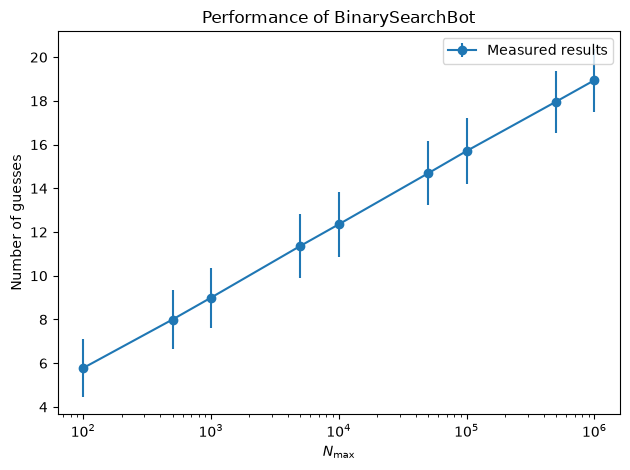

In [15]:
import numpy as np

size_array = np.array(list(dataset_binary_search_bot), dtype=int)
data_array = np.array([data.quarentiles for data in dataset_binary_search_bot.values()]).T

fig, ax = plt.subplots()
ax.errorbar(size_array,
            np.array([data.mean for data in dataset_binary_search_bot.values()]),
            np.array([data.std for data in dataset_binary_search_bot.values()]),
            marker='o',
            label='Measured results'
            )

ax.set_xlabel('$N_\\text{max}$')
ax.set_ylabel('Number of guesses')
ax.set_title('Performance of BinarySearchBot')
ax.set_xscale('log')
ax.legend()
fig.tight_layout()